### Create SMET Forcing Files from Met Station Data (filled with HRRR-AK (lapse-rate temp)): Point Simulation at the PPSA
* Including lapse-rate correction with HRRR-AK temperature data 

created by Cassie Lumbrazo\
last updated: July 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/ppsa'

## Load Tram Data: Cleaned in `1_clean_met_ppsa_synoptic.ipynb'

In [3]:
# open observations
file = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20"  # should really replace this with the WY2026 data once I fix that...
ds_met = xr.open_dataset(file)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_met = ds_met.sel(time=slice("2019-10-01T05:00:00", "2025-09-30T05:00:00"))

# convert temp to K for comparison with HRRR-AK data
ds_met['temp'] = ds_met['temp'] + 273.15
ds_met

<xarray.Dataset> Size: 3MB
Dimensions:           (time: 47195)
Coordinates:
  * time              (time) datetime64[ns] 378kB 2019-10-01T05:00:00 ... 202...
Data variables:
    temp              (time) float64 378kB 277.3 277.6 278.0 ... 277.6 276.4
    rh                (time) float64 378kB ...
    hs                (time) float64 378kB ...
    precip_accum      (time) float64 378kB ...
    precip_rate       (time) float64 378kB ...
    precip_accum_1hr  (time) float64 378kB ...

_________________________________________________________________

## Load the HRRR-AK Dataset

In [4]:
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc"
ds_hrrr = xr.open_dataset(input_file)
ds_hrrr.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

# and clip to WY2020,2021,2022 
ds_hrrr = ds_hrrr.sel(time=slice("2019-10-01T05:00:00", "2025-09-30T05:00:00"))

ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

# remove any precip accum that are above 20
ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_accum_1hr'].where(ds_hrrr['precip_accum_1hr'] < 20)

HRRR to MeteIO Variable Mapping 

In [5]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [6]:
from pathlib import Path
from pyproj import Transformer

In [7]:
lat_ppsa, lon_ppsa, elevation_ppsa = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [8]:
# relate the variables, df_met is for the met station data 
ds_met = ds_met.copy()

# ds is for the HRRRAK data
ds_hrrrak = ds_hrrr.copy()

New Code, 


Lapse-rate correction:
Site elevation: 670.00 m
HRRR elevation: 585.55 m
Elevation difference, site - HRRR: 84.45 m
Temperature correction applied to HRRR fill TA: -0.51 K

Original dataset ranges:
MET:  2019-10-01T05:00:00.000000000 -> 2025-09-30T05:00:00.000000000
HRRR: 2019-10-01T05:00:00.000000000 -> 2025-09-30T05:00:00.000000000

Coverage statistics:
MET precip valid fraction: 0.8974422363791956
HRRR precip valid fraction: 0.9999619663402111
MET TA valid fraction: 0.8974802700389845
HRRR TA fill valid fraction: 0.9999809831701055

Fraction of timesteps using MET data:
TA: 0.8974802700389845
RH: 0.8974802700389845
PSUM: 0.8974422363791956

Fill source diagnostics:
MET TA timesteps used: 47194
HRRR lapse-rate TA fill timesteps: 5391
Missing final TA timesteps: 0
MET RH timesteps used: 47194
HRRR raw RH fill timesteps: 5391
Missing final RH timesteps: 0
MET PSUM timesteps used: 47192
HRRR raw PSUM fill timesteps: 5393
Missing final PSUM timesteps: 0

PSUM totals:
MET PSUM total: 185

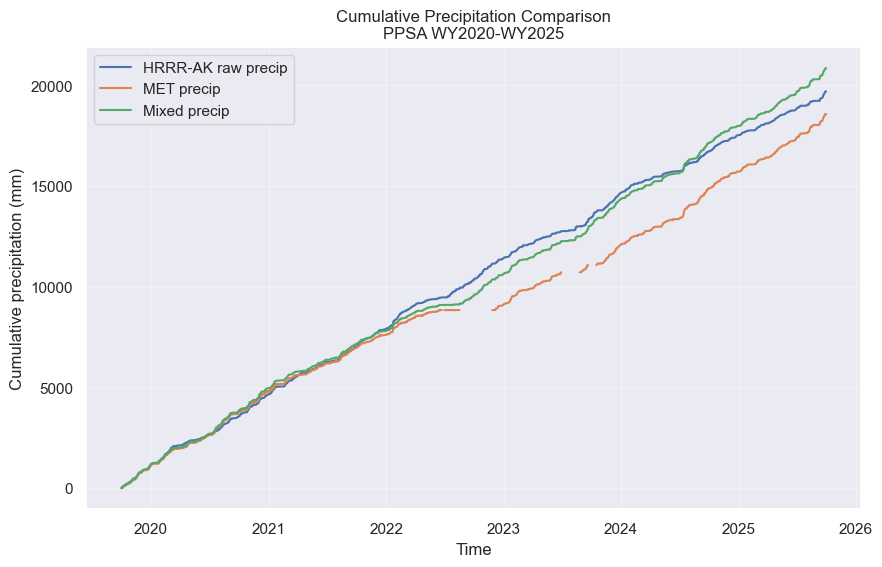

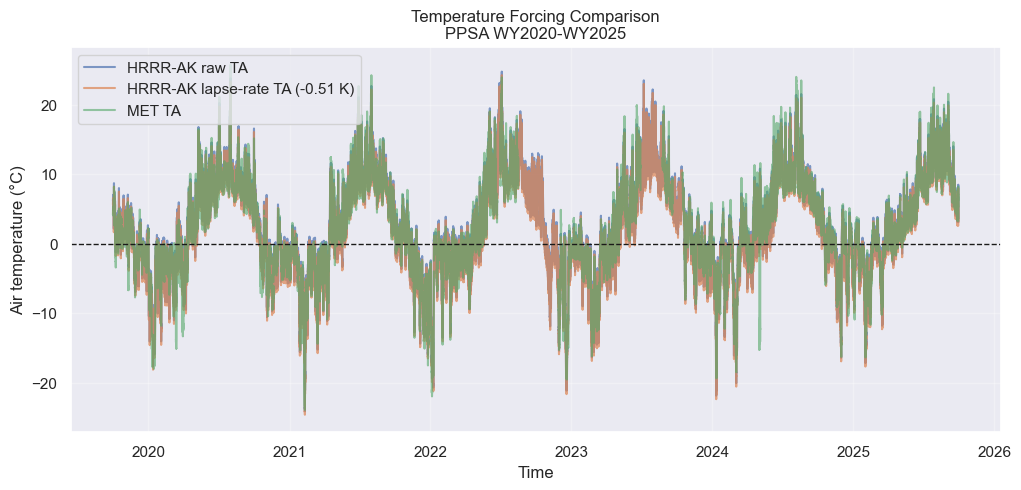

In [9]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================

start_time = "2019-10-01T05:00"
end_time   = "2025-09-30T05:00"

TIMESTEP = "1h"

OUTFILE = Path(
    "/home/cassie/python/models/run_snowpack/sites/ppsa/input/"
    "/met_hrrrak_lapserate_WY2020-WY2025/met_hrrrak_lapserate_ppsa_WY2020-WY2025.smet"
)

STATION_ID   = "met_hrrrak_lapserate_ppsa_WY2020-WY2025"
STATION_NAME = "Met Station and HRRR-AK Lapse-rate Temperature PPSA Point Forcing"

LAT  = lat_ppsa
LON  = lon_ppsa
ELEV = elevation_ppsa

# HRRR-AK grid-cell elevation at PPSA
HRRR_ELEV = 585.55

# Lapse rate: positive value, K/m or degC/m
LAPSE_RATE = 0.006

EPSG   = 32608
TZ     = 0
NODATA = -999

# ============================================================
# TEMPERATURE LAPSE-RATE CORRECTION
# ============================================================

elevation_difference = ELEV - HRRR_ELEV
temperature_correction = -LAPSE_RATE * elevation_difference

print("\nLapse-rate correction:")
print(f"Site elevation: {ELEV:.2f} m")
print(f"HRRR elevation: {HRRR_ELEV:.2f} m")
print(f"Elevation difference, site - HRRR: {elevation_difference:.2f} m")
print(f"Temperature correction applied to HRRR fill TA: {temperature_correction:+.2f} K")

# ============================================================
# SLICE TO COMMON TIME RANGE
# ============================================================

ds_met = ds_met.sel(time=slice(start_time, end_time))
ds_hrrrak = ds_hrrrak.sel(time=slice(start_time, end_time))

print("\nOriginal dataset ranges:")
print(f"MET:  {ds_met.time.min().values} -> {ds_met.time.max().values}")
print(f"HRRR: {ds_hrrrak.time.min().values} -> {ds_hrrrak.time.max().values}")

# ============================================================
# SORT TIME AXES
# ============================================================

ds_met = ds_met.sortby("time")
ds_hrrrak = ds_hrrrak.sortby("time")

# ============================================================
# CREATE CONTINUOUS HOURLY TIME AXES
# ============================================================

ds_met = ds_met.resample(time="1h").asfreq()
ds_hrrrak = ds_hrrrak.resample(time="1h").asfreq()

# ============================================================
# ALIGN MET DATA TO HRRR TIME AXIS
# ============================================================

ds_met = ds_met.reindex(time=ds_hrrrak.time)

# ============================================================
# PRECIPITATION CHECK
# ============================================================

if "precip_accum_1hr" not in ds_met:
    raise KeyError(
        "ds_met['precip_accum_1hr'] does not exist. "
        "Create it in the upstream MET precipitation-cleaning script first."
    )

ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(
    ds_met["precip_accum_1hr"] >= 0
)

ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(
    ds_met["precip_accum_1hr"] <= 40
)

# ============================================================
# UNIT CONVERSIONS
# ============================================================

# RH: convert to fraction only if currently percent
if float(ds_met["rh"].max(skipna=True)) > 1.5:
    ds_met["rh"] = ds_met["rh"] / 100.0

if float(ds_hrrrak["rh"].max(skipna=True)) > 1.5:
    ds_hrrrak["rh"] = ds_hrrrak["rh"] / 100.0

# TA: keep in Kelvin for SNOWPACK
# Apply lapse-rate correction only to HRRR-AK temperature fill
ds_hrrrak["temp_lapserate"] = ds_hrrrak["temp"] + temperature_correction

# ============================================================
# DIAGNOSTIC CHECKS
# ============================================================

print("\nCoverage statistics:")
print("MET precip valid fraction:", float(ds_met["precip_accum_1hr"].notnull().mean()))
print("HRRR precip valid fraction:", float(ds_hrrrak["precip_accum_1hr"].notnull().mean()))
print("MET TA valid fraction:", float(ds_met["temp"].notnull().mean()))
print("HRRR TA fill valid fraction:", float(ds_hrrrak["temp_lapserate"].notnull().mean()))

# ============================================================
# CREATE FINAL FILLED FORCING DATASET
# ============================================================

ds_filled = xr.Dataset(coords={"time": ds_hrrrak.time})

# MET first, HRRR-AK fill
# Only the HRRR-AK temperature fill is lapse-rate corrected
ds_filled["TA"] = ds_met["temp"].combine_first(ds_hrrrak["temp_lapserate"])
ds_filled["RH"] = ds_met["rh"].combine_first(ds_hrrrak["rh"])
ds_filled["PSUM"] = ds_met["precip_accum_1hr"].combine_first(
    ds_hrrrak["precip_accum_1hr"]
)

# Always raw HRRR-AK
ds_filled["ISWR"] = ds_hrrrak["swrad"]
ds_filled["ILWR"] = ds_hrrrak["lwrad"]
ds_filled["PS"]   = ds_hrrrak["pressure"]

u = ds_hrrrak["10u"]
v = ds_hrrrak["10v"]

ds_filled["VW"] = np.sqrt(u**2 + v**2)
ds_filled["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0

# ============================================================
# DIAGNOSTIC OUTPUT
# ============================================================

met_ta_used = ds_met["temp"].notnull()
hrrr_ta_fill_used = ds_met["temp"].isnull() & ds_hrrrak["temp_lapserate"].notnull()

met_rh_used = ds_met["rh"].notnull()
hrrr_rh_fill_used = ds_met["rh"].isnull() & ds_hrrrak["rh"].notnull()

met_psum_used = ds_met["precip_accum_1hr"].notnull()
hrrr_psum_fill_used = (
    ds_met["precip_accum_1hr"].isnull()
    & ds_hrrrak["precip_accum_1hr"].notnull()
)

print("\nFraction of timesteps using MET data:")
print("TA:", float(met_ta_used.mean()))
print("RH:", float(met_rh_used.mean()))
print("PSUM:", float(met_psum_used.mean()))

print("\nFill source diagnostics:")
print("MET TA timesteps used:", int(met_ta_used.sum()))
print("HRRR lapse-rate TA fill timesteps:", int(hrrr_ta_fill_used.sum()))
print("Missing final TA timesteps:", int(ds_filled["TA"].isnull().sum()))

print("MET RH timesteps used:", int(met_rh_used.sum()))
print("HRRR raw RH fill timesteps:", int(hrrr_rh_fill_used.sum()))
print("Missing final RH timesteps:", int(ds_filled["RH"].isnull().sum()))

print("MET PSUM timesteps used:", int(met_psum_used.sum()))
print("HRRR raw PSUM fill timesteps:", int(hrrr_psum_fill_used.sum()))
print("Missing final PSUM timesteps:", int(ds_filled["PSUM"].isnull().sum()))

print("\nPSUM totals:")
print("MET PSUM total:", float(ds_met["precip_accum_1hr"].sum(skipna=True)))
print("HRRR PSUM total:", float(ds_hrrrak["precip_accum_1hr"].sum(skipna=True)))
print("Final mixed PSUM total:", float(ds_filled["PSUM"].sum(skipna=True)))

# ============================================================
# FREEZING-THRESHOLD DIAGNOSTIC FOR HRRR TA FILLS
# ============================================================

FREEZING_K = 273.15

raw_above_lapse_below = (
    hrrr_ta_fill_used
    & (ds_hrrrak["temp"] > FREEZING_K)
    & (ds_hrrrak["temp_lapserate"] <= FREEZING_K)
)

raw_below_lapse_above = (
    hrrr_ta_fill_used
    & (ds_hrrrak["temp"] <= FREEZING_K)
    & (ds_hrrrak["temp_lapserate"] > FREEZING_K)
)

precip_during_fill = (
    hrrr_ta_fill_used
    & ds_filled["PSUM"].notnull()
    & (ds_filled["PSUM"] > 0.1)
)

raw_above_lapse_below_precip = raw_above_lapse_below & precip_during_fill
raw_below_lapse_above_precip = raw_below_lapse_above & precip_during_fill

print("\n===== TA fill freezing-threshold diagnostic =====")
print("HRRR TA fill timesteps:", int(hrrr_ta_fill_used.sum()))
print("Raw HRRR > 0°C, lapse-rate HRRR <= 0°C:", int(raw_above_lapse_below.sum()))
print("Raw HRRR <= 0°C, lapse-rate HRRR > 0°C:", int(raw_below_lapse_above.sum()))

print("\n===== TA fill freezing-threshold diagnostic during precip =====")
print("HRRR TA fill timesteps with precip > 0.1 mm/hr:", int(precip_during_fill.sum()))
print("Raw HRRR > 0°C, lapse-rate HRRR <= 0°C:", int(raw_above_lapse_below_precip.sum()))
print("Raw HRRR <= 0°C, lapse-rate HRRR > 0°C:", int(raw_below_lapse_above_precip.sum()))

# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

df_smet = ds_filled.to_dataframe()
df_smet = df_smet.asfreq(TIMESTEP)
df_smet = df_smet.fillna(NODATA)

# ============================================================
# COORDINATE TRANSFORM
# ============================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)

# ============================================================
# WRITE SMET FILE
# ============================================================

OUTFILE.parent.mkdir(parents=True, exist_ok=True)

with open(OUTFILE, "w") as f:

    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write(
        "source           = MET temperature, relative humidity, and precipitation "
        "filled with HRRR-AK; HRRR-AK temperature fill lapse-rate corrected to site elevation\n"
    )
    f.write(f"lapse_rate       = {LAPSE_RATE:.4f} K m-1\n")
    f.write(f"hrrr_elevation   = {HRRR_ELEV:.2f} m\n")
    f.write(f"site_elevation   = {ELEV:.2f} m\n")
    f.write(f"ta_correction    = {temperature_correction:.3f} K\n")

    f.write("fields           = timestamp TA RH VW DW ISWR ILWR PSUM PS\n")
    f.write("[DATA]\n")

    for t, row in df_smet.iterrows():
        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} "
            f"{row.RH:6.3f} "
            f"{row.VW:6.2f} "
            f"{row.DW:6.1f} "
            f"{row.ISWR:8.1f} "
            f"{row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} "
            f"{row.PS:8.1f}\n"
        )

print(f"\nSMET file written to:\n{OUTFILE}")

# ============================================================
# PRECIPITATION COMPARISON PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(ds_hrrrak["precip_accum_1hr"].to_series().cumsum(), label="HRRR-AK raw precip")
plt.plot(ds_met["precip_accum_1hr"].to_series().cumsum(), label="MET precip")
plt.plot(ds_filled["PSUM"].to_series().cumsum(), label="Mixed precip")

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")
plt.title("Cumulative Precipitation Comparison\nPPSA WY2020-WY2025")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# TEMPERATURE FILL DIAGNOSTIC PLOT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot((ds_hrrrak["temp"] - 273.15).to_series(), label="HRRR-AK raw TA", alpha=0.7)
plt.plot(
    (ds_hrrrak["temp_lapserate"] - 273.15).to_series(),
    label=f"HRRR-AK lapse-rate TA ({temperature_correction:+.2f} K)",
    alpha=0.7,
)
plt.plot((ds_met["temp"] - 273.15).to_series(), label="MET TA", alpha=0.6)

plt.ylabel("Air temperature (°C)")
plt.xlabel("Time")
plt.title("Temperature Forcing Comparison\nPPSA WY2020-WY2025")
plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Create .SNO File 

In [10]:
# ============================================================
# CREATE EMPTY .SNO FILE
# ============================================================

# ============================================================
# OUTPUT FILE
# ============================================================

OUTFILE_SNO = OUTFILE.with_suffix(".sno")
OUTFILE_SNO.parent.mkdir(parents=True, exist_ok=True)

# ============================================================
# PROFILE DATE
# ============================================================

# Use the first timestamp in the final SMET dataframe
forcing_start_time = df_smet.index.min()

# SNOWPACK commonly initializes one timestep after forcing start
profile_date = pd.to_datetime(forcing_start_time) + pd.to_timedelta(TIMESTEP)
profile_date_str = profile_date.strftime("%Y-%m-%dT%H:%M")

# ============================================================
# OPTIONAL SITE PARAMETERS
# ============================================================

SLOPE_ANGLE = 38.0
SLOPE_AZI   = 0.0

SOIL_ALBEDO = 0.09
BARE_SOIL_Z0 = 0.200

CANOPY_HEIGHT = 0.00
CANOPY_LAI = 0.00
CANOPY_DIRECT_THROUGHFALL = 1.00

WIND_SCALING_FACTOR = 1.00

# ============================================================
# WRITE SNO FILE
# ============================================================

with open(OUTFILE_SNO, "w") as f:

    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write(
        "source           = MET temperature, relative humidity, and precipitation "
        "filled with HRRR-AK; HRRR-AK temperature fill lapse-rate corrected to site elevation\n"
    )
    f.write(f"lapse_rate       = {LAPSE_RATE:.4f} K m-1\n")
    f.write(f"hrrr_elevation   = {HRRR_ELEV:.2f} m\n")
    f.write(f"site_elevation   = {ELEV:.2f} m\n")
    f.write(f"ta_correction    = {temperature_correction:.3f} K\n")

    f.write(f"ProfileDate      = {profile_date_str}\n")
    f.write("HS_Last          = 0.0000\n")

    f.write(f"SlopeAngle       = {SLOPE_ANGLE:.1f}\n")
    f.write(f"SlopeAzi         = {SLOPE_AZI:.1f}\n")

    f.write("nSoilLayerData   = 0\n")
    f.write("nSnowLayerData   = 0\n")

    f.write(f"SoilAlbedo       = {SOIL_ALBEDO:.2f}\n")
    f.write(f"BareSoil_z0      = {BARE_SOIL_Z0:.3f}\n")

    f.write(f"CanopyHeight     = {CANOPY_HEIGHT:.2f}\n")
    f.write(f"CanopyLeafAreaIndex = {CANOPY_LAI:.2f}\n")
    f.write(f"CanopyDirectThroughfall = {CANOPY_DIRECT_THROUGHFALL:.2f}\n")
    f.write(f"WindScalingFactor = {WIND_SCALING_FACTOR:.2f}\n")

    f.write("ErosionLevel     = 0\n")
    f.write("TimeCountDeltaHS = 0.000000\n")

    f.write(
        "fields           = "
        "timestamp Layer_Thick T Vol_Frac_I "
        "Vol_Frac_W Vol_Frac_V Vol_Frac_S "
        "Rho_S Conduc_S HeatCapac_S "
        "rg rb dd sp mk mass_hoar ne CDot metamo\n"
    )

    f.write("[DATA]\n")

print(f"\nSNO file written to:\n{OUTFILE_SNO}")


SNO file written to:
/home/cassie/python/models/run_snowpack/sites/ppsa/input/met_hrrrak_lapserate_WY2020-WY2025/met_hrrrak_lapserate_ppsa_WY2020-WY2025.sno


In [11]:
# ============================================================
# TEMPERATURE FILL / FREEZING THRESHOLD DIAGNOSTICS
# ============================================================

FREEZING_K = 273.15

# Timesteps where MET temperature is missing,
# so HRRR-AK temperature is actually used as the TA fill
hrrr_ta_fill_used = (
    ds_met["temp"].isnull()
    & ds_hrrrak["temp"].notnull()
)

# Raw HRRR and lapse-rate corrected HRRR temperatures during fill timesteps
ta_raw_fill = ds_hrrrak["temp"].where(hrrr_ta_fill_used)
ta_lapse_fill = ds_hrrrak["temp_lapserate"].where(hrrr_ta_fill_used)

# Phase-relevant threshold changes
raw_above_lapse_below = (
    hrrr_ta_fill_used
    & (ds_hrrrak["temp"] > FREEZING_K)
    & (ds_hrrrak["temp_lapserate"] <= FREEZING_K)
)

raw_below_lapse_above = (
    hrrr_ta_fill_used
    & (ds_hrrrak["temp"] <= FREEZING_K)
    & (ds_hrrrak["temp_lapserate"] > FREEZING_K)
)

n_fill = int(hrrr_ta_fill_used.sum())
n_raw_above_lapse_below = int(raw_above_lapse_below.sum())
n_raw_below_lapse_above = int(raw_below_lapse_above.sum())

print("\n===== TA fill freezing-threshold diagnostic =====")
print(f"HRRR TA fill timesteps: {n_fill}")
print(
    "Raw HRRR > 0°C, lapse-rate HRRR <= 0°C:",
    n_raw_above_lapse_below
)
print(
    "Raw HRRR <= 0°C, lapse-rate HRRR > 0°C:",
    n_raw_below_lapse_above
)

if n_fill > 0:
    print(
        "Fraction of HRRR TA fill timesteps crossing freezing:",
        f"{100 * (n_raw_above_lapse_below + n_raw_below_lapse_above) / n_fill:.2f}%"
    )

# Optional: same diagnostic only during precipitation
precip_during_fill = (
    hrrr_ta_fill_used
    & ds_filled["PSUM"].notnull()
    & (ds_filled["PSUM"] > 0.1)
)

raw_above_lapse_below_precip = raw_above_lapse_below & precip_during_fill
raw_below_lapse_above_precip = raw_below_lapse_above & precip_during_fill

n_fill_precip = int(precip_during_fill.sum())
n_raw_above_lapse_below_precip = int(raw_above_lapse_below_precip.sum())
n_raw_below_lapse_above_precip = int(raw_below_lapse_above_precip.sum())

precip_raw_above_lapse_below = float(
    ds_filled["PSUM"].where(raw_above_lapse_below_precip).sum(skipna=True)
)

precip_raw_below_lapse_above = float(
    ds_filled["PSUM"].where(raw_below_lapse_above_precip).sum(skipna=True)
)

print("\n===== TA fill freezing-threshold diagnostic during precip =====")
print(f"HRRR TA fill timesteps with precip > 0.1 mm/hr: {n_fill_precip}")
print(
    "Raw HRRR > 0°C, lapse-rate HRRR <= 0°C:",
    n_raw_above_lapse_below_precip,
    f"({precip_raw_above_lapse_below:.1f} mm precip)"
)
print(
    "Raw HRRR <= 0°C, lapse-rate HRRR > 0°C:",
    n_raw_below_lapse_above_precip,
    f"({precip_raw_below_lapse_above:.1f} mm precip)"
)


===== TA fill freezing-threshold diagnostic =====
HRRR TA fill timesteps: 5391
Raw HRRR > 0°C, lapse-rate HRRR <= 0°C: 140
Raw HRRR <= 0°C, lapse-rate HRRR > 0°C: 0
Fraction of HRRR TA fill timesteps crossing freezing: 2.60%

===== TA fill freezing-threshold diagnostic during precip =====
HRRR TA fill timesteps with precip > 0.1 mm/hr: 1372
Raw HRRR > 0°C, lapse-rate HRRR <= 0°C: 73 (102.9 mm precip)
Raw HRRR <= 0°C, lapse-rate HRRR > 0°C: 0 (0.0 mm precip)


## Plot Forcing Data Figure 

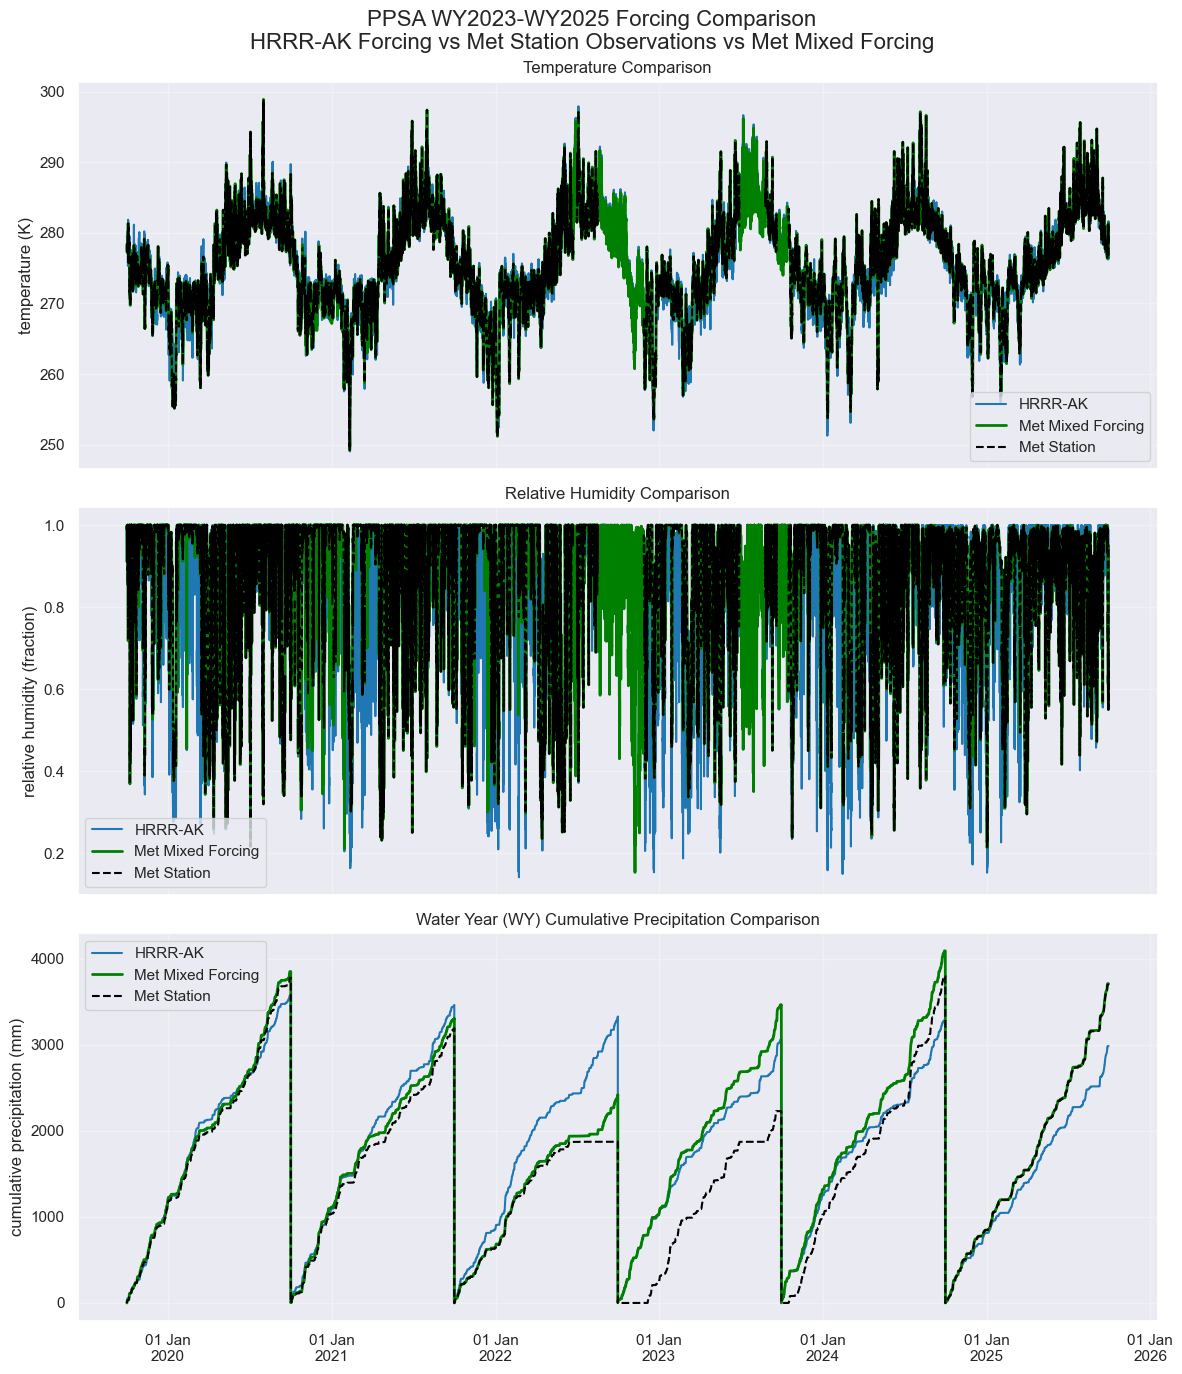

In [16]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ============================================================
# MULTI-VARIABLE COMPARISON PLOT
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14),
    sharex=True
)

# ============================================================
# TEMPERATURE
# ============================================================

ax = axes[0]

# All datasets already aligned and in Kelvin

ax.plot(
    ds_hrrrak["temp"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_filled["TA"].to_series(),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2
)

ax.plot(
    ds_met["temp"].to_series(),
    label="Met Station",
    color="black",
    linestyle="--",
    
)

ax.set_ylabel("temperature (K)")
ax.set_title("Temperature Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# RELATIVE HUMIDITY
# ============================================================

ax = axes[1]

# RH already converted to fraction [0-1]

ax.plot(
    ds_hrrrak["rh"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_filled["RH"].to_series(),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2
)

ax.plot(
    ds_met["rh"].to_series(),
    label="Met Station",
    color="black",
    linestyle="--",
)

ax.set_ylabel("relative humidity (fraction)")
ax.set_title("Relative Humidity Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# PRECIPITATION
# ============================================================

ax = axes[2]

def wateryear_cumsum(da, wy_start_month=10):
    """
    Cumulative sum that resets at the start of each water year.
    Water year starts on Oct 1 by default.
    """
    s = da.fillna(0).to_series()

    # Water year label: Oct-Dec belong to next calendar year
    wy = s.index.year + (s.index.month >= wy_start_month)

    return s.groupby(wy).cumsum()


ax.plot(
    wateryear_cumsum(ds_hrrrak["precip_accum_1hr"]),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    wateryear_cumsum(ds_filled["PSUM"]),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2,
)

ax.plot(
    wateryear_cumsum(ds_met["precip_accum_1hr"]),
    label="Met Station",
    color="black",
    linestyle="--",
)

ax.set_ylabel("cumulative precipitation (mm)")
ax.set_title("Water Year (WY) Cumulative Precipitation Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# COMMON X-AXIS
# ============================================================

def custom_date_formatter(x, pos):
    dt = mdates.num2date(x)
    return dt.strftime("%d %b\n%Y")

axes[-1].xaxis.set_major_formatter(
    FuncFormatter(custom_date_formatter)
)

axes[-1].set_xlabel("")

plt.suptitle(
    "PPSA WY2023-WY2025 Forcing Comparison\n"
    "HRRR-AK Forcing vs Met Station Observations vs Met Mixed Forcing",
    fontsize=16
)

plt.tight_layout()

plt.show()